# Patient Curve Assistant 


In [ ]:
%pip install openpyxl matplotlib seaborn scikit-learn scipy plotly nbformat pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd 
import numpy as np 
import requests
from io import BytesIO

# URLs for WHO child growth standards
urls = {
    "girls_wfa_0-13w_z": "https://cdn.who.int/media/docs/default-source/child-growth/child-growth-standards/indicators/weight-for-age/wfa_girls_0-to-13-weeks_zscores.xlsx?sfvrsn=c4f4ba9f_7",
    "girls_wfa_0-5y_z": "https://cdn.who.int/media/docs/default-source/child-growth/child-growth-standards/indicators/weight-for-age/wfa_girls_0-to-5-years_zscores.xlsx?sfvrsn=4c03b8db_7",
    "boys_wfa_0-13w_z": "https://cdn.who.int/media/docs/default-source/child-growth/child-growth-standards/indicators/weight-for-age/wfa_boys_0-to-13-weeks_zscores.xlsx?sfvrsn=6e3a980f_7",
    "boys_wfa_0-5y_z": "https://cdn.who.int/media/docs/default-source/child-growth/child-growth-standards/indicators/weight-for-age/wfa_boys_0-to-5-years_zscores.xlsx?sfvrsn=97a05331_9",
    "girls_expanded_z": "https://cdn.who.int/media/docs/default-source/child-growth/child-growth-standards/indicators/weight-for-age/expanded-tables/wfa-girls-zscore-expanded-tables.xlsx?sfvrsn=f01bc813_10",
    "boys_expanded_z": "https://cdn.who.int/media/docs/default-source/child-growth/child-growth-standards/indicators/weight-for-age/expanded-tables/wfa-boys-zscore-expanded-tables.xlsx?sfvrsn=1c8b9e5f_10",
    "girls_expanded_pct": "https://cdn.who.int/media/docs/default-source/child-growth/child-growth-standards/indicators/weight-for-age/expanded-tables/wfa-girls-percentiles-expanded-tables.xlsx?sfvrsn=1c8b9e5f_10",
    "boys_expanded_pct": "https://cdn.who.int/media/docs/default-source/child-growth/child-growth-standards/indicators/weight-for-age/expanded-tables/wfa-boys-percentiles-expanded-tables.xlsx?sfvrsn=1c8b9e5f_10"
}

dataframes = {}

for key, url in urls.items():
    response = requests.get(url)
    print(f"Downloading {key}: HTTP status {response.status_code}")
    if response.status_code != 200:
        raise RuntimeError(f"Failed to download {key}, status {response.status_code}")
    bytes_buf = BytesIO(response.content)
    dataframes[key] = pd.read_excel(bytes_buf, engine="openpyxl")

# Assign to variables
girls_weight_for_age_dataframe_b13 = dataframes["girls_wfa_0-13w_z"]
girls_weight_for_age_dataframe_b5y = dataframes["girls_wfa_0-5y_z"]
boys_weight_for_age_dataframe_b13 = dataframes["boys_wfa_0-13w_z"]
boys_weight_for_age_dataframe_b5y = dataframes["boys_wfa_0-5y_z"]
girls_expanded_tables_zscores = dataframes["girls_expanded_z"]
boys_expanded_tables_zscores = dataframes["boys_expanded_z"]
girls_expanded_tables_percentiles = dataframes["girls_expanded_pct"]
boys_expanded_tables_percentiles = dataframes["boys_expanded_pct"]

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import scipy.interpolate as interp
import plotly.graph_objects as go

# Check nbformat version
try:
    import nbformat
    print(f"nbformat version: {nbformat.__version__}")
except ImportError:
    print("nbformat not installed")

nbformat version: 5.10.4


In [6]:
# Test nbformat import
import nbformat
print(f"nbformat imported successfully, version: {nbformat.__version__}")

# Also check plotly's nbformat detection
import plotly 
print(f"plotly.io nbformat check: {plotly.__version__}")

nbformat imported successfully, version: 5.10.4
plotly.io nbformat check: 6.6.0


In [7]:
# Get predicted centile from age and weight input
def get_predicted_centile(age_in_days, weight_in_kg, sex):
    """
    Calculate the weight-for-age percentile for a given age, weight, and sex.
    
    Parameters:
    age_in_days (float): Age in days
    weight_in_kg (float): Weight in kg
    sex (str): 'female' or 'male'
    
    Returns:
    float: Percentile (0-100)
    """
    if sex == "female":
        df = girls_expanded_tables_percentiles
    elif sex == "male":
        df = boys_expanded_tables_percentiles
    else:
        raise ValueError("Sex must be 'female' or 'male'")
    
    # Assume first column is age, others are percentiles P01, P1, P3, ..., P99, P999
    age_col = df.columns[0]
    percentile_cols = [col for col in df.columns if col.startswith('P')]
    
    # Find the closest age
    ages = df[age_col].values
    idx = np.searchsorted(ages, age_in_days) - 1
    if idx < 0:
        idx = 0
    elif idx >= len(ages) - 1:
        idx = len(ages) - 2
    
    age1, age2 = ages[idx], ages[idx+1]
    if age1 == age2:
        # Exact match
        weights = df.iloc[idx][percentile_cols].values
    else:
        # Interpolate between ages
        w1 = df.iloc[idx][percentile_cols].values
        w2 = df.iloc[idx+1][percentile_cols].values
        weights = w1 + (w2 - w1) * (age_in_days - age1) / (age2 - age1)
    
    percentiles = [float(col[1:]) for col in percentile_cols]  # Remove 'P' and convert to float
    
    # Find where weight falls
    if weight_in_kg <= weights[0]:
        return percentiles[0]
    elif weight_in_kg >= weights[-1]:
        return percentiles[-1]
    else:
        # Interpolate percentile
        f = interp.interp1d(weights, percentiles, kind='linear', bounds_error=False, fill_value='extrapolate')
        return f(weight_in_kg)

# Example usage
centile = get_predicted_centile(30, 3.5, 'female')
print(f"Centile for 30 days, 3.5kg, female: {centile:.1f}")

Centile for 30 days, 3.5kg, female: 10.4


In [8]:
# Explore data structure
print("Girls expanded percentiles shape:", girls_expanded_tables_percentiles.shape)
print("Columns:", girls_expanded_tables_percentiles.columns.tolist()[:10])
print("First few rows:")
girls_expanded_tables_percentiles.head()

Girls expanded percentiles shape: (1857, 19)
Columns: ['Age', 'L', 'M', 'S', 'P01', 'P1', 'P3', 'P5', 'P10', 'P15']
First few rows:


,Age,L,M,S,P01,P1,P3,P5,P10,P15,P25,P50,P75,P85,P90,P95,P97,P99,P999
0,0,0.3809,3.2322,0.14171,2.002,2.273,2.440,2.532,2.678,2.779,2.932,3.232,3.550,3.729,3.853,4.041,4.166,4.409,4.846
1,1,0.3259,3.1957,0.14578,1.963,2.231,2.398,2.490,2.635,2.737,2.892,3.196,3.520,3.704,3.831,4.026,4.155,4.408,4.865
2,2,0.3101,3.2104,0.14637,1.972,2.240,2.408,2.500,2.646,2.748,2.904,3.210,3.538,3.723,3.853,4.049,4.181,4.438,4.902
3,3,0.2986,3.2315,0.14657,1.986,2.255,2.424,2.516,2.663,2.766,2.923,3.232,3.562,3.749,3.879,4.079,4.212,4.471,4.942
4,4,0.2891,3.2558,0.14658,2.004,2.274,2.443,2.536,2.684,2.787,2.945,3.256,3.589,3.778,3.909,4.110,4.245,4.507,4.983


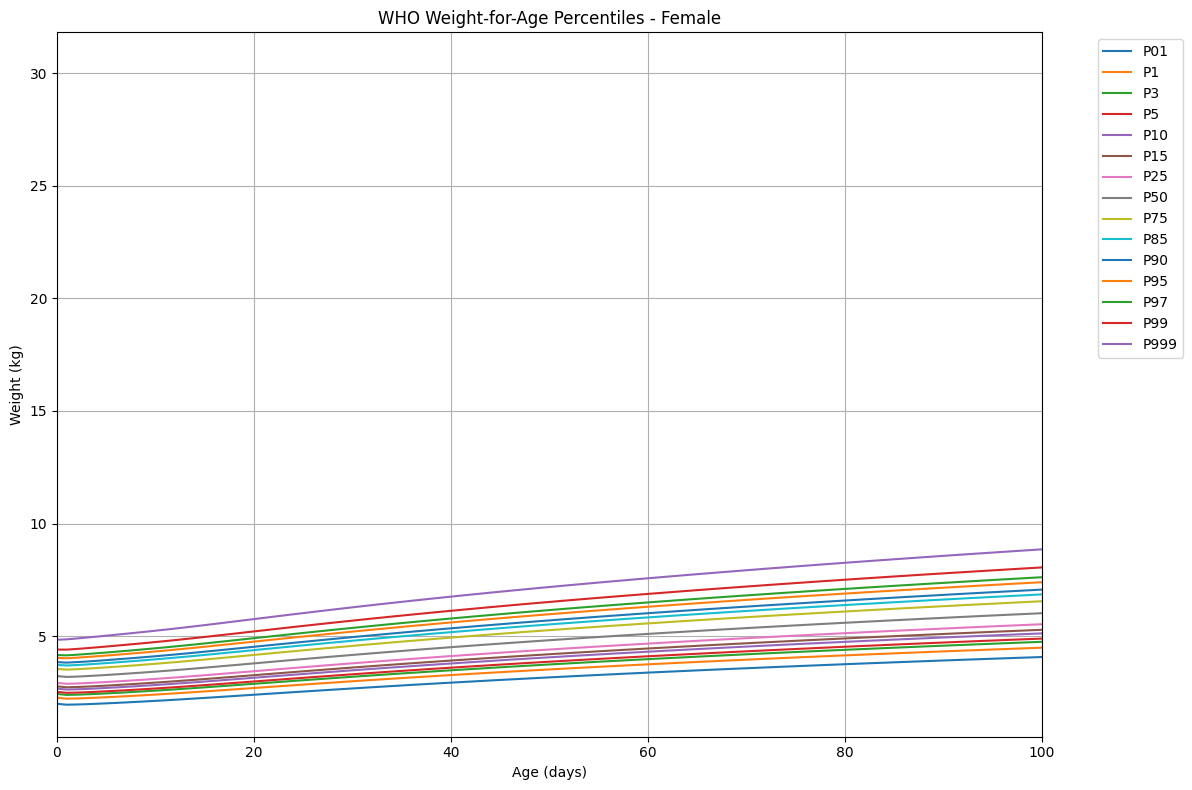

In [9]:
# Plot growth curves
def plot_growth_curves(sex='female', age_range_days=(0, 365)):
    if sex == 'female':
        df = girls_expanded_tables_percentiles
    else:
        df = boys_expanded_tables_percentiles
    
    age_col = df.columns[0]
    percentile_cols = [col for col in df.columns if col.startswith('P')]
    
    plt.figure(figsize=(12, 8))
    for col in percentile_cols:
        plt.plot(df[age_col], df[col], label=col)
    
    plt.xlabel('Age (days)')
    plt.ylabel('Weight (kg)')
    plt.title(f'WHO Weight-for-Age Percentiles - {sex.capitalize()}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.xlim(age_range_days)
    plt.tight_layout()
    plt.show()

plot_growth_curves('female', (0, 100))  # First 100 days

In [10]:
# Patient data analysis
# Example patient data
patient_data = pd.DataFrame({
    'age_days': [7, 14, 21, 30, 60, 90],
    'weight_kg': [3.0, 3.2, 3.5, 4.0, 5.5, 7.0],
    'sex': ['female'] * 6
})

# Calculate centiles for patient
patient_data['centile'] = patient_data.apply(
    lambda row: get_predicted_centile(row['age_days'], row['weight_kg'], row['sex']), axis=1
)

print("Patient growth data with centiles:")
patient_data

# Plot patient curve against standards
def plot_patient_vs_standards(patient_df, sex='female'):
    fig = go.Figure()
    
    # Add percentile curves
    if sex == 'female':
        df = girls_expanded_tables_percentiles
    else:
        df = boys_expanded_tables_percentiles
    
    age_col = df.columns[0]
    percentile_cols = ['P3', 'P5', 'P10', 'P25', 'P50', 'P75', 'P90', 'P95', 'P97']
    
    colors = ['lightblue', 'blue', 'green', 'orange', 'red', 'orange', 'green', 'blue', 'lightblue']
    for i, col in enumerate(percentile_cols):
        fig.add_trace(go.Scatter(
            x=df[age_col], y=df[col], mode='lines',
            name=f'{col} ({float(col[1:]):.0f}th percentile)',
            line=dict(color=colors[i % len(colors)], width=1)
        ))
    
    # Add patient data
    fig.add_trace(go.Scatter(
        x=patient_df['age_days'], y=patient_df['weight_kg'], mode='lines+markers',
        name='Patient',
        line=dict(color='black', width=3),
        marker=dict(size=8, color='red')
    ))
    
    fig.update_layout(
        title=f'Patient Growth Curve vs WHO Standards ({sex.capitalize()})',
        xaxis_title='Age (days)',
        yaxis_title='Weight (kg)',
        showlegend=True
    )
    
    # Save as HTML and display
    fig.write_html("growth_chart.html")
    print("Chart saved as growth_chart.html")
    
    # Try to show inline, if fails, suggest opening HTML
    try:
        fig.show()
    except ValueError as e:
        print(f"Inline display failed: {e}")
        print("Please open growth_chart.html in your browser to view the chart.")

plot_patient_vs_standards(patient_data, 'female')

Patient growth data with centiles:
Chart saved as growth_chart.html


# Summary

This notebook provides a Patient Curve Assistant for analyzing child growth using WHO standards:

1. **Data Loading**: Downloads and loads WHO child growth standards for weight-for-age percentiles and z-scores for both girls and boys.

2. **Centile Calculation**: Implements `get_predicted_centile()` function to calculate the percentile for a given age, weight, and sex using interpolation.

3. **Visualization**: 
   - Plots WHO growth curves for selected percentiles
   - Compares patient data against standards using interactive Plotly charts

4. **Usage**: 
   - Modify `patient_data` DataFrame with actual patient measurements
   - Run the analysis to get centiles and visualizations
   - Use for monitoring growth trends and identifying potential issues

The assistant helps healthcare professionals assess child growth patterns and identify deviations from normal growth trajectories.